# Analiza ewaluacji modeli — porównanie międzymodelowe (wspólny podzbiór 4k)

Sprawiedliwe porównanie **1:1** czterech modeli na tych samych 4 000 stwierdzeniach
(zbudowane przez `tools/build_subsample_results_db.py` -> `results/results_am_subsample.db`).

| Model | Pokrycie |
|---|---|
| Bielik-11B | pełny benchmark, tu ograniczony do 4k |
| PLLuM-8B | podzbiór 4k |
| llama3.1:8b | pełny benchmark, tu ograniczony do 4k |
| qwen2.5:7b | podzbiór 4k |

Agenci ga1-ga7 (zero-shot -> debata kontradyktoryjna + RAG). Kolejność modeli:
**najpierw modele polskie (Bielik, PLLuM), następnie llama i qwen.**

In [1]:
import re
import sqlite3
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgb

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.3)
plt.rcParams["figure.dpi"] = 110

plt.rcParams.update({
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "legend.title_fontsize": 12,
    "figure.titlesize": 16,
})

conn = sqlite3.connect("../results/results_am_subsample.db")

# Kolejnosc: najpierw modele polskie (Bielik, PLLuM), potem llama, qwen.
PALETTE = {
    "Bielik-11B":  "#E07B54",   # pomaranczowy
    "PLLuM-8B":    "#C44E52",   # czerwony
    "llama3.1:8b": "#4C72B0",   # niebieski
    "qwen2.5:7b":  "#8172B3",   # fioletowy (wyraznie odrozniany od niebieskiego)
}
MODEL_ORDER = ["Bielik-11B", "PLLuM-8B", "llama3.1:8b", "qwen2.5:7b"]

def _short_model(m):
    m = str(m)
    if "Bielik" in m: return "Bielik-11B"
    if "PLLuM"  in m: return "PLLuM-8B"
    if "qwen"   in m: return "qwen2.5:7b"
    return "llama3.1:8b"

AGENT_META = {
    "uam_ga1": ("ga1\nZero-shot",    1),
    "uam_ga2": ("ga2\nWeb ReAct",    1),
    "uam_ga3": ("ga3\nBM25",         1),
    "uam_ga4": ("ga4\nRAG+Decomp",   2),
    "uam_ga5": ("ga5\nBM25+Decomp",  2),
    "uam_ga6": ("ga6\nFewShot+RAG",  3),
    "uam_ga7": ("ga7\nDebate+RAG",   3),
}
AGENT_ORDER = list(AGENT_META.keys())
LABEL_ORDER = [v[0] for v in AGENT_META.values()]

In [2]:
# Master dataframe: results joined to benchmark claims (topic / year / type)
df = pd.read_sql_query("""
    SELECT r.agent_name, r.model_name, r.claim_id, r.is_correct,
           r.model_label, r.original_label,
           r.time_thought, r.total_tokens, r.prompt_tokens, r.completion_tokens,
           r.created_at, c.topic, c.claim_date, c.exam_type
    FROM agent_results r
    LEFT JOIN claims c ON c.id = r.claim_id
    WHERE r.agent_name NOT LIKE 'uam_ga_web_tool_arch%'
""", conn)

df["model"]      = df["model_name"].apply(_short_model)
df["base_agent"] = df["agent_name"].str.extract(r"^(uam_ga\d+)")
df["label"]      = df["base_agent"].map(lambda a: AGENT_META.get(a, (a, 0))[0])
df["tier"]       = df["base_agent"].map(lambda a: AGENT_META.get(a, (a, 0))[1])
df["created_at"] = pd.to_datetime(df["created_at"], utc=True, errors="coerce")
df["year"]       = pd.to_numeric(df["claim_date"], errors="coerce")

VALID = {"0", "1", "2", "3"}
# Predicted labels that are not 0-3 (ERROR_MAX_STEPS, floats, ...) -> INVALID.
# Accuracy uses the stored is_correct; INVALID rows count as incorrect.
df["pred_bucket"] = df["model_label"].where(df["model_label"].isin(VALID), "INVALID")

print(f"{len(df):,} rows | {df['base_agent'].nunique()} agents | "
      f"{df['model'].nunique()} models | {df['claim_id'].nunique():,} claims")
print("INVALID predictions:",
      (df['pred_bucket'] == 'INVALID').sum(),
      f"({(df['pred_bucket']=='INVALID').mean()*100:.2f}%)")
df.head(3)

96,000 rows | 6 agents | 4 models | 4,000 claims
INVALID predictions: 4560 (4.75%)


,agent_name,model_name,claim_id,is_correct,model_label,original_label,time_thought,total_tokens,prompt_tokens,completion_tokens,created_at,topic,claim_date,exam_type,model,base_agent,label,tier,year,pred_bucket
0,uam_ga1__hf.co-speakleash-Bielik-11B-v2.3-Inst...,hf.co/speakleash/Bielik-11B-v2.3-Instruct-GGUF...,6,0,4: Brak odpowiedzi w podanych opcjach.\n\nRzec...,3,8.969152,991,281,710,2026-04-07 20:38:17.728112+00:00,Przyroda,2010,Egzaminy Gimnazjalne,Bielik-11B,uam_ga1,ga1\nZero-shot,1,2010,INVALID
1,uam_ga2__hf.co-speakleash-Bielik-11B-v2.3-Inst...,hf.co/speakleash/Bielik-11B-v2.3-Instruct-GGUF...,6,0,0,3,19.878185,1706,1042,664,2026-04-12 08:20:10.954165+00:00,Przyroda,2010,Egzaminy Gimnazjalne,Bielik-11B,uam_ga2,ga2\nWeb ReAct,1,2010,0
2,uam_ga4__hf.co-speakleash-Bielik-11B-v2.3-Inst...,hf.co/speakleash/Bielik-11B-v2.3-Instruct-GGUF...,6,1,3,3,5.767691,1744,1363,381,2026-04-13 03:26:11.187238+00:00,Przyroda,2010,Egzaminy Gimnazjalne,Bielik-11B,uam_ga4,ga4\nRAG+Decomp,2,2010,3


In [3]:
_present = set(df["base_agent"].unique())
AGENT_ORDER = [a for a in AGENT_META if a in _present]
LABEL_ORDER = [AGENT_META[a][0] for a in AGENT_ORDER]
print("Agenci obecni w danych:", ", ".join(AGENT_ORDER))

Agenci obecni w danych: uam_ga1, uam_ga2, uam_ga3, uam_ga4, uam_ga5, uam_ga6


## Tabele przestawne — dokładność i koszt wg agenta x modelu

In [4]:
def _order(p):
    return p.reindex(index=AGENT_ORDER, columns=MODEL_ORDER)

# 1) Accuracy (%) per agent x model
acc_pivot = (_order(df.pivot_table("is_correct", "base_agent", "model", "mean")) * 100).round(1)
acc_pivot

model,Bielik-11B,PLLuM-8B,llama3.1:8b,qwen2.5:7b
base_agent,,,,
uam_ga1,45.9,26.7,35.0,42.9
uam_ga2,44.0,30.9,35.2,40.7
uam_ga3,44.9,32.1,29.0,43.0
uam_ga4,44.8,32.9,28.8,43.5
uam_ga5,29.4,30.0,28.6,28.4
uam_ga6,23.4,19.6,26.4,28.9


In [5]:
# 2) Total tokens consumed per agent x model
tok_pivot = _order(df.pivot_table("total_tokens", "base_agent", "model", "sum")).astype("Int64")
tok_pivot

model,Bielik-11B,PLLuM-8B,llama3.1:8b,qwen2.5:7b
base_agent,,,,
uam_ga1,2617559,1317086,1733599,1127430
uam_ga2,4600116,3572010,3922677,3599224
uam_ga3,9734812,5543673,6827114,5182176
uam_ga4,9690252,5550985,6860625,5128290
uam_ga5,68770764,43535901,56336540,42461461
uam_ga6,111998770,60170632,95622403,75190812


In [6]:
# 3) Avg prompt:completion token ratio per agent x model
avg_p = df.pivot_table("prompt_tokens", "base_agent", "model", "mean")
avg_c = df.pivot_table("completion_tokens", "base_agent", "model", "mean")
ratio_pivot = _order(avg_p / avg_c).round(2)
ratio_pivot

model,Bielik-11B,PLLuM-8B,llama3.1:8b,qwen2.5:7b
base_agent,,,,
uam_ga1,0.79,6.91,1.30,4.55
uam_ga2,4.11,12.58,3.99,6.87
uam_ga3,4.27,12.13,15.86,26.41
uam_ga4,4.32,11.89,15.64,26.06
uam_ga5,4.79,6.91,6.13,5.37
uam_ga6,6.79,11.03,7.97,5.33


In [7]:
# 4) Avg evaluation time (s) per claim, per agent x model
time_pivot = _order(df.pivot_table("time_thought", "base_agent", "model", "mean")).round(2)
time_pivot

model,Bielik-11B,PLLuM-8B,llama3.1:8b,qwen2.5:7b
base_agent,,,,
uam_ga1,4.62,0.55,1.77,0.58
uam_ga2,3.60,2.91,2.46,2.42
uam_ga3,8.28,2.72,2.40,1.59
uam_ga4,7.67,2.69,2.42,1.63
uam_ga5,46.51,16.93,22.16,17.50
uam_ga6,61.40,17.74,32.70,31.94


In [8]:
# 5) Master summary table (all metrics, per agent x model)
summary = pd.read_sql_query("""
    SELECT agent_name, model_name,
           COUNT(*)                                                    AS n,
           ROUND(100.0*SUM(is_correct)/COUNT(*), 2)                    AS accuracy_pct,
           SUM(total_tokens)                                           AS total_tokens,
           ROUND(AVG(prompt_tokens), 1)                               AS avg_prompt_tokens,
           ROUND(AVG(completion_tokens), 1)                           AS avg_completion_tokens,
           ROUND(AVG(prompt_tokens)/NULLIF(AVG(completion_tokens),0), 2) AS prompt_completion_ratio,
           ROUND(AVG(time_thought), 3)                                AS avg_time_s,
           ROUND(AVG(time_thought)/NULLIF(AVG(total_tokens),0), 6)    AS avg_time_per_token,
           ROUND(SUM(total_tokens)/NULLIF(SUM(is_correct),0), 1)      AS tokens_per_correct
    FROM agent_results
    GROUP BY agent_name, model_name
    ORDER BY agent_name, model_name
""", conn)
summary["model"] = summary["model_name"].apply(_short_model)
summary

,agent_name,model_name,n,accuracy_pct,total_tokens,avg_prompt_tokens,avg_completion_tokens,prompt_completion_ratio,avg_time_s,avg_time_per_token,tokens_per_correct,model
0,uam_ga1__hf.co-mradermacher-Llama-PLLuM-8B-ins...,hf.co/mradermacher/Llama-PLLuM-8B-instruct-GGU...,4000,26.68,1317086,287.7,41.6,6.91,0.551,0.001673,1234.0,PLLuM-8B
1,uam_ga1__hf.co-speakleash-Bielik-11B-v2.3-Inst...,hf.co/speakleash/Bielik-11B-v2.3-Instruct-GGUF...,4000,45.92,2617559,288.9,365.5,0.79,4.617,0.007056,1424.0,Bielik-11B
2,uam_ga1__llama3.1-8b,llama3.1:8b,4000,34.98,1733599,244.7,188.7,1.30,1.769,0.004081,1239.0,llama3.1:8b
3,uam_ga1__qwen2.5-7b,qwen2.5:7b,4000,42.92,1127430,231.1,50.8,4.55,0.584,0.002072,656.0,qwen2.5:7b
4,uam_ga2__hf.co-mradermacher-Llama-PLLuM-8B-ins...,hf.co/mradermacher/Llama-PLLuM-8B-instruct-GGU...,4000,30.93,3572010,827.2,65.8,12.58,2.910,0.003259,2887.0,PLLuM-8B
5,uam_ga2__hf.co-speakleash-Bielik-11B-v2.3-Inst...,hf.co/speakleash/Bielik-11B-v2.3-Instruct-GGUF...,4000,44.02,4600116,925.1,224.9,4.11,3.601,0.003131,2612.0,Bielik-11B
6,uam_ga2__llama3.1-8b,llama3.1:8b,4000,35.17,3922677,784.2,196.4,3.99,2.460,0.002509,2787.0,llama3.1:8b
7,uam_ga2__qwen2.5-7b,qwen2.5:7b,4000,40.73,3599224,785.5,114.3,6.87,2.417,0.002687,2209.0,qwen2.5:7b
8,uam_ga3__hf.co-mradermacher-Llama-PLLuM-8B-ins...,hf.co/mradermacher/Llama-PLLuM-8B-instruct-GGU...,4000,32.13,5543673,1280.3,105.6,12.13,2.725,0.001966,4314.0,PLLuM-8B
9,uam_ga3__hf.co-speakleash-Bielik-11B-v2.3-Inst...,hf.co/speakleash/Bielik-11B-v2.3-Instruct-GGUF...,4000,44.92,9734812,1972.2,461.5,4.27,8.283,0.003403,5417.0,Bielik-11B


## Wizualizacje

In [9]:
# Agregat per (agent, model) wraz z tokenami wej/wyj; pomocnik do wykresow slupkowych
agent_summary = (
    df.groupby(["base_agent", "model", "label", "tier"], observed=True)
      .agg(accuracy_pct  =("is_correct", lambda s: s.mean() * 100),
           median_time   =("time_thought", "median"),
           avg_time      =("time_thought", "mean"),
           avg_tokens    =("total_tokens", "mean"),
           avg_prompt    =("prompt_tokens", "mean"),
           avg_completion=("completion_tokens", "mean"))
      .reset_index()
)
agent_summary["label"] = pd.Categorical(agent_summary["label"], LABEL_ORDER, ordered=True)
agent_summary = agent_summary.sort_values(["label", "model"])

# Wydajnosc wzgledem dokladnosci (nizej = lepiej)
eff = agent_summary.copy()
eff["acc_frac"]       = eff["accuracy_pct"] / 100
eff["time_per_acc"]   = eff["avg_time"]   / eff["acc_frac"]
eff["tokens_per_acc"] = eff["avg_tokens"] / eff["acc_frac"]

def agent_model_bar(data, value, title, ylabel, fmt="%.0f", rot=0, figsize=(13, 6)):
    """Pojedynczy wykres slupkowy agent x model w spojnej kolorystyce."""
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(data=data, x="label", y=value, hue="model",
                hue_order=MODEL_ORDER, palette=PALETTE, order=LABEL_ORDER, ax=ax)
    for c in ax.containers:
        ax.bar_label(c, fmt=fmt, padding=2, fontsize=7, rotation=rot)
    ax.set_title(title, fontsize=15, fontweight="bold")
    ax.set_xlabel("Agent  →  rosnąca złożoność"); ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", labelsize=12); ax.legend(title="Model", fontsize=11)
    ax.margins(y=0.14)
    plt.tight_layout(); plt.show()

### Wykres 1 — Dokładność według agenta i modelu

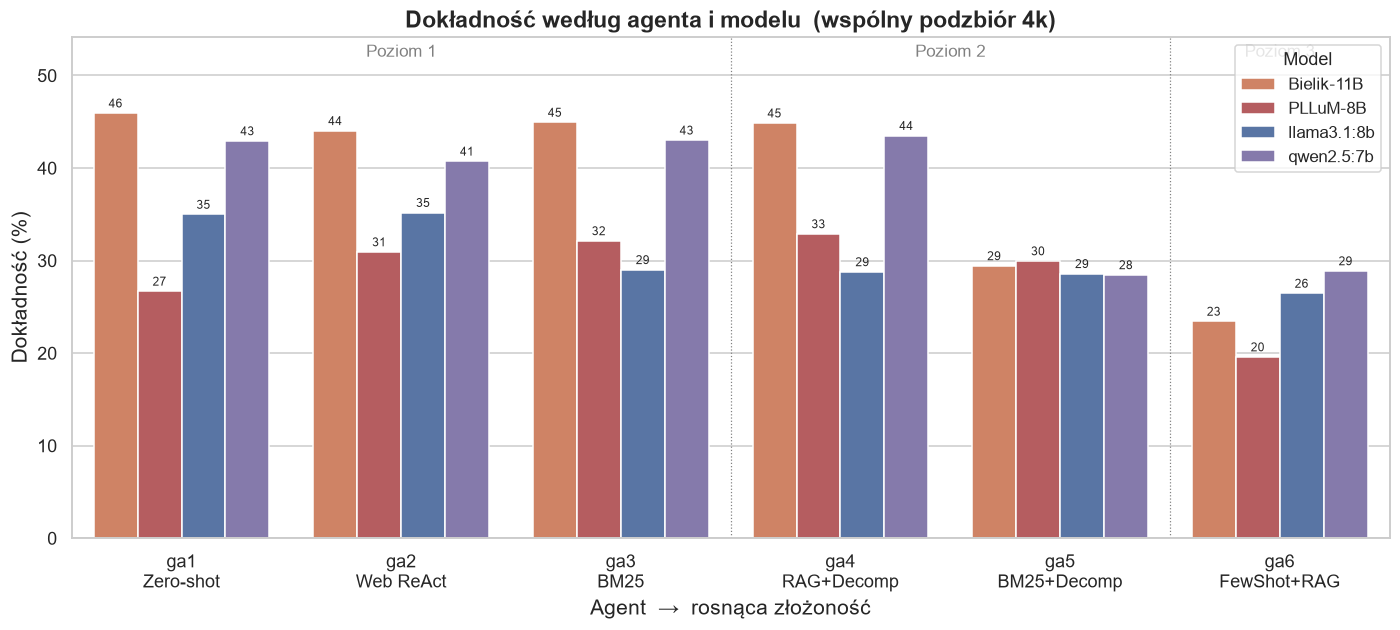

In [10]:
fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=agent_summary, x="label", y="accuracy_pct", hue="model",
            hue_order=MODEL_ORDER, palette=PALETTE, order=LABEL_ORDER, ax=ax)
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f", padding=2, fontsize=8)
ymax = agent_summary["accuracy_pct"].max() * 1.18
ax.set_ylim(0, ymax)
for x in (2.5, 4.5):
    ax.axvline(x, color="grey", lw=0.8, ls=":")
for x, lbl in ((1.0, "Poziom 1"), (3.5, "Poziom 2"), (5.0, "Poziom 3")):
    ax.text(x, ymax * 0.96, lbl, ha="center", fontsize=11, color="grey")
ax.set_title("Dokładność według agenta i modelu  (wspólny podzbiór 4k)",
             fontsize=15, fontweight="bold")
ax.set_xlabel("Agent  →  rosnąca złożoność"); ax.set_ylabel("Dokładność (%)")
ax.tick_params(axis="x", labelsize=12); ax.legend(title="Model", fontsize=11)
plt.tight_layout(); plt.show()

### Wykres 1b — Skumulowana średnia dokładność wśród agentów

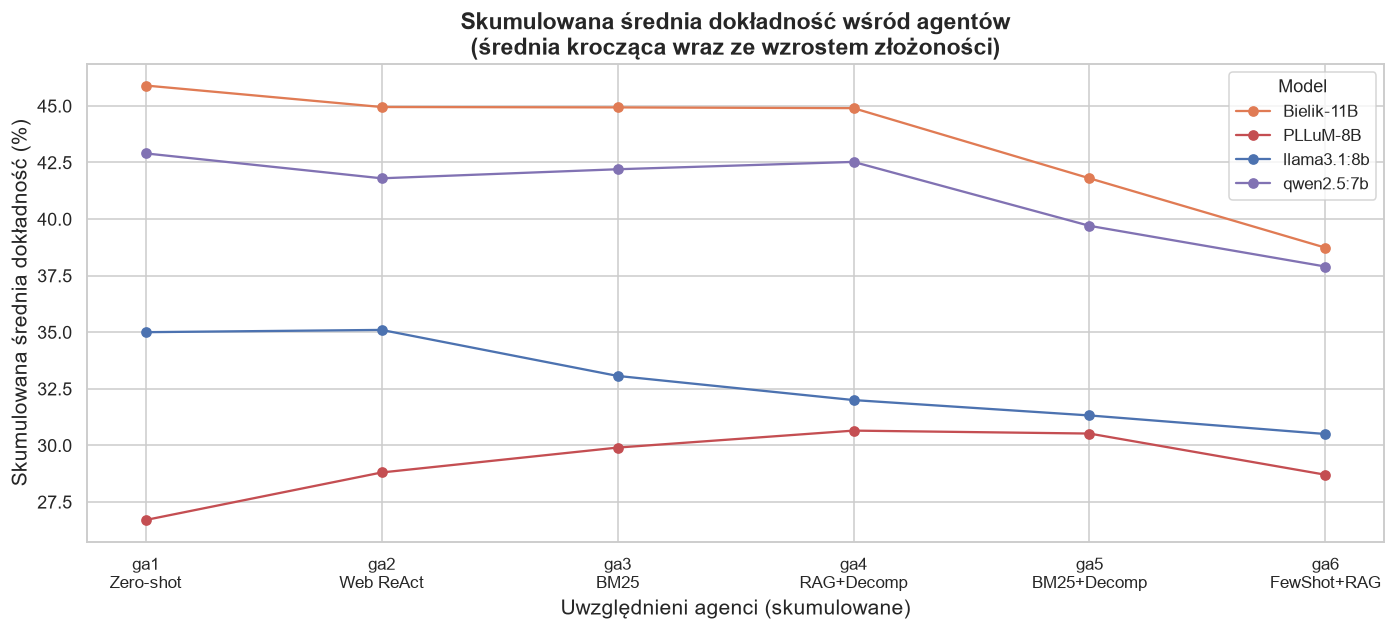

In [11]:
acc_pivot = (df.pivot_table("is_correct", "base_agent", "model", "mean")
               .reindex(index=AGENT_ORDER, columns=MODEL_ORDER) * 100).round(1)
fig, ax = plt.subplots(figsize=(13, 6))
for m in MODEL_ORDER:
    cum = acc_pivot[m].expanding().mean()
    ax.plot(range(len(acc_pivot)), cum, marker="o", color=PALETTE[m], label=m)
ax.set_xticks(range(len(acc_pivot)))
ax.set_xticklabels([AGENT_META[a][0] for a in acc_pivot.index], fontsize=11)
ax.set_title("Skumulowana średnia dokładność wśród agentów\n(średnia krocząca wraz ze wzrostem złożoności)",
             fontsize=15, fontweight="bold")
ax.set_xlabel("Uwzględnieni agenci (skumulowane)")
ax.set_ylabel("Skumulowana średnia dokładność (%)")
ax.legend(title="Model", fontsize=11)
plt.tight_layout(); plt.show()

### Wykres 2 — Dokładność krocząca według indeksu (wszystkie modele)

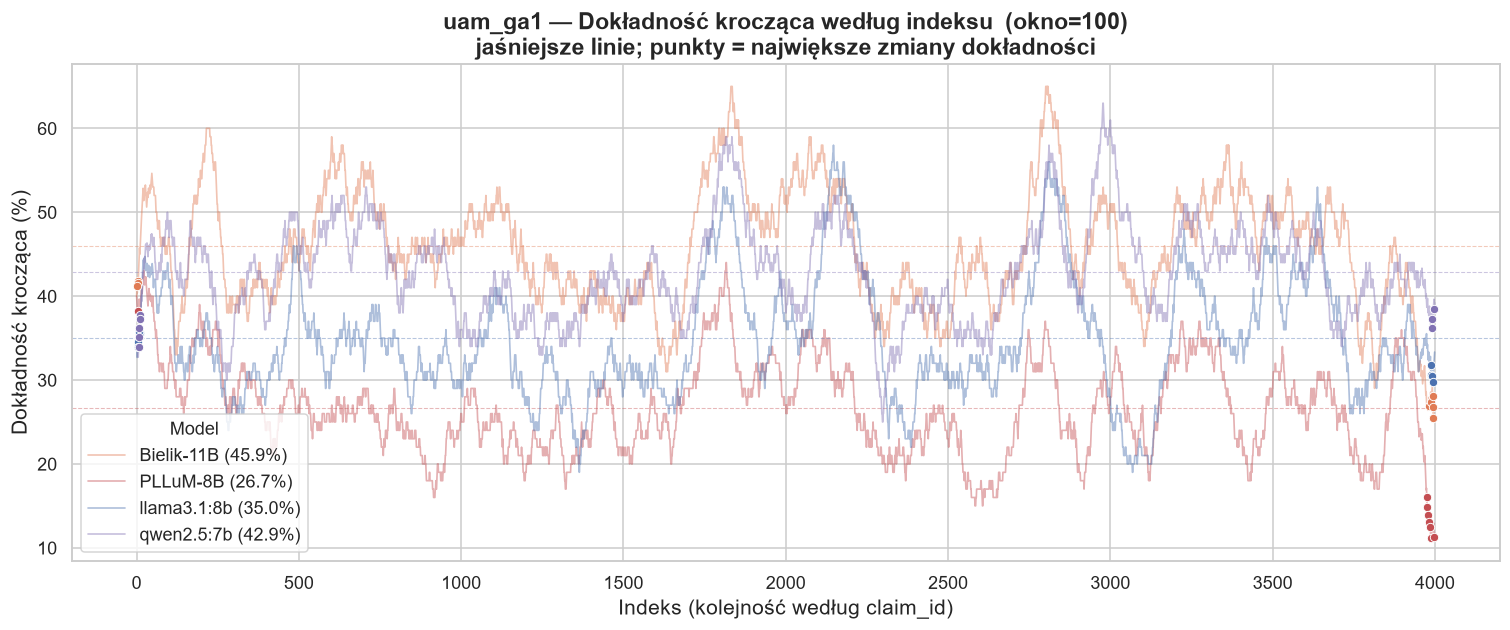

In [12]:
WINDOW = 100
AGENT_ROLL = "uam_ga1"
sub = df[df.base_agent == AGENT_ROLL]

fig, ax = plt.subplots(figsize=(14, 6))
roll_by_model = {}
for m in MODEL_ORDER:
    g = sub[sub.model == m].sort_values("claim_id").reset_index(drop=True)
    roll = g["is_correct"].rolling(WINDOW, center=True, min_periods=30).mean() * 100
    rv = pd.Series(roll.values).interpolate(limit_direction="both").values
    roll_by_model[m] = rv
    idx = np.arange(len(rv))
    overall = g["is_correct"].mean() * 100
    ax.plot(idx, rv, color=PALETTE[m], lw=1.1, alpha=0.45, label=f"{m} ({overall:.1f}%)")
    ax.axhline(overall, color=PALETTE[m], ls="--", lw=0.7, alpha=0.4)
    delta = np.abs(np.diff(rv, prepend=rv[0]))
    top = np.argsort(delta)[-8:]
    ax.scatter(idx[top], rv[top], color=PALETTE[m], s=30,
               edgecolors="white", lw=0.6, zorder=5)
ax.set_title(f"{AGENT_ROLL} — Dokładność krocząca według indeksu  (okno={WINDOW})\n"
             "jaśniejsze linie; punkty = największe zmiany dokładności",
             fontsize=15, fontweight="bold")
ax.set_xlabel("Indeks (kolejność według claim_id)")
ax.set_ylabel("Dokładność krocząca (%)")
ax.legend(title="Model", fontsize=12)
plt.tight_layout(); plt.show()

### Wykres 2b — Średnia dokładność krocząca po wszystkich modelach

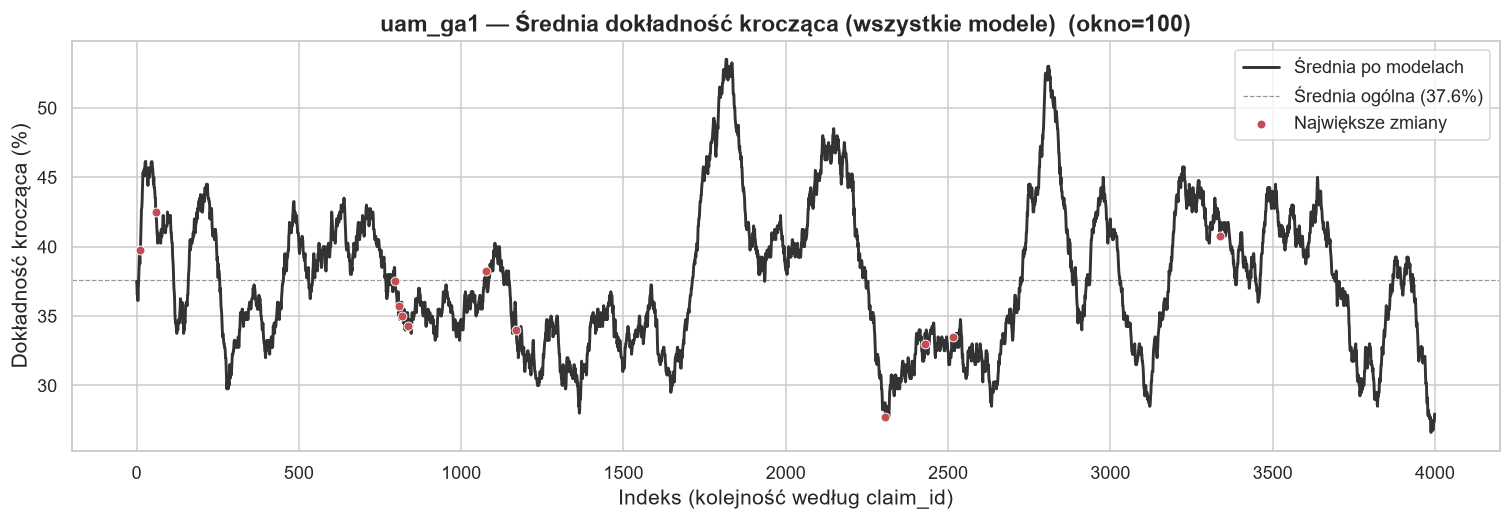

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))
avg = np.mean(np.vstack([roll_by_model[m] for m in MODEL_ORDER]), axis=0)
idx = np.arange(len(avg))
ax.plot(idx, avg, color="#333333", lw=1.9, label="Średnia po modelach")
overall = float(np.mean(avg))
ax.axhline(overall, color="#333333", ls="--", lw=0.8, alpha=0.5,
           label=f"Średnia ogólna ({overall:.1f}%)")
delta = np.abs(np.diff(avg, prepend=avg[0]))
top = np.argsort(delta)[-12:]
ax.scatter(idx[top], avg[top], color="#C44E52", s=34, edgecolors="white", lw=0.6,
           zorder=5, label="Największe zmiany")
ax.set_title(f"{AGENT_ROLL} — Średnia dokładność krocząca (wszystkie modele)  (okno={WINDOW})",
             fontsize=15, fontweight="bold")
ax.set_xlabel("Indeks (kolejność według claim_id)")
ax.set_ylabel("Dokładność krocząca (%)")
ax.legend(fontsize=12)
plt.tight_layout(); plt.show()

### Wykres 3 — Dokładność i wydajność według złożoności

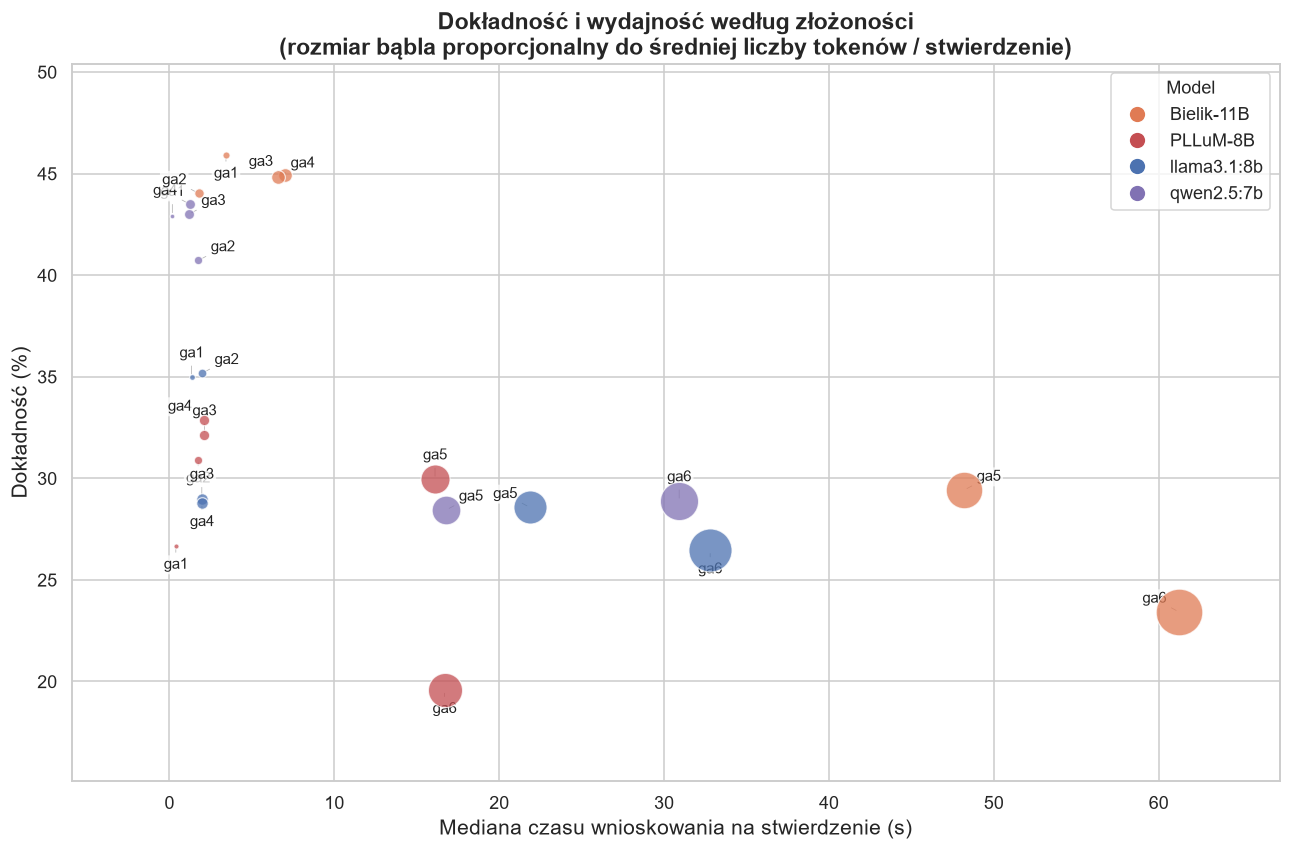

In [14]:
fig, ax = plt.subplots(figsize=(12, 8))
pts = []
for _, r in agent_summary.iterrows():
    ax.scatter(r["median_time"], r["accuracy_pct"], color=PALETTE[r["model"]],
               s=r["avg_tokens"] / 30, alpha=0.75, edgecolors="white", lw=0.8, zorder=5)
    pts.append((r["median_time"], r["accuracy_pct"], r["label"].split("\n")[0]))

pts.sort(key=lambda p: (p[0], p[1]))
offsets = [(0, 13), (0, -15), (16, 6), (-16, 6)]
for i, (x, y, lab) in enumerate(pts):
    dx, dy = offsets[i % 4]
    ax.annotate(lab, (x, y), xytext=(dx, dy), textcoords="offset points",
                fontsize=10, color="#222", ha="center",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75),
                arrowprops=dict(arrowstyle="-", lw=0.5, color="grey", alpha=0.6))
handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=PALETTE[m],
                  markersize=11, label=m) for m in MODEL_ORDER]
ax.legend(handles=handles, title="Model", fontsize=12)
ax.set_xlabel("Mediana czasu wnioskowania na stwierdzenie (s)")
ax.set_ylabel("Dokładność (%)")
ax.set_title("Dokładność i wydajność według złożoności\n(rozmiar bąbla proporcjonalny do średniej liczby tokenów / stwierdzenie)",
             fontsize=15, fontweight="bold")
ax.margins(x=0.10, y=0.17)
plt.tight_layout(); plt.show()

### Wykres 3b/3c — Średnia liczba tokenów wejściowych i wyjściowych na stwierdzenie

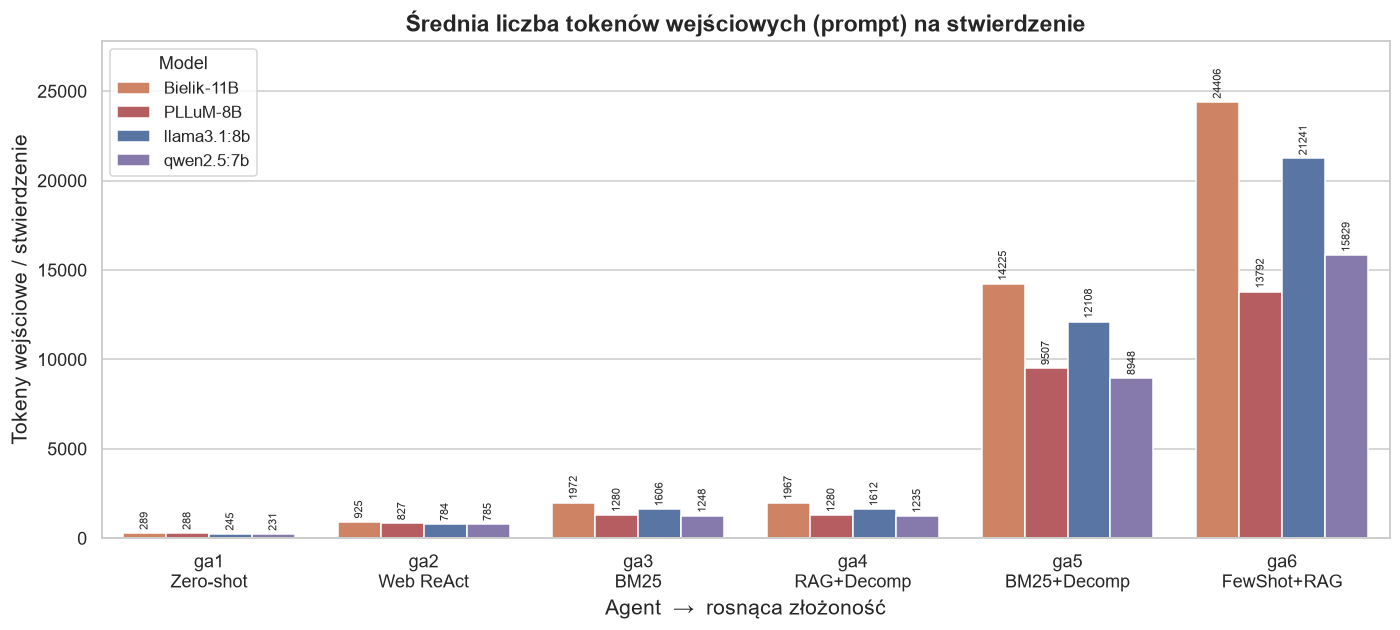

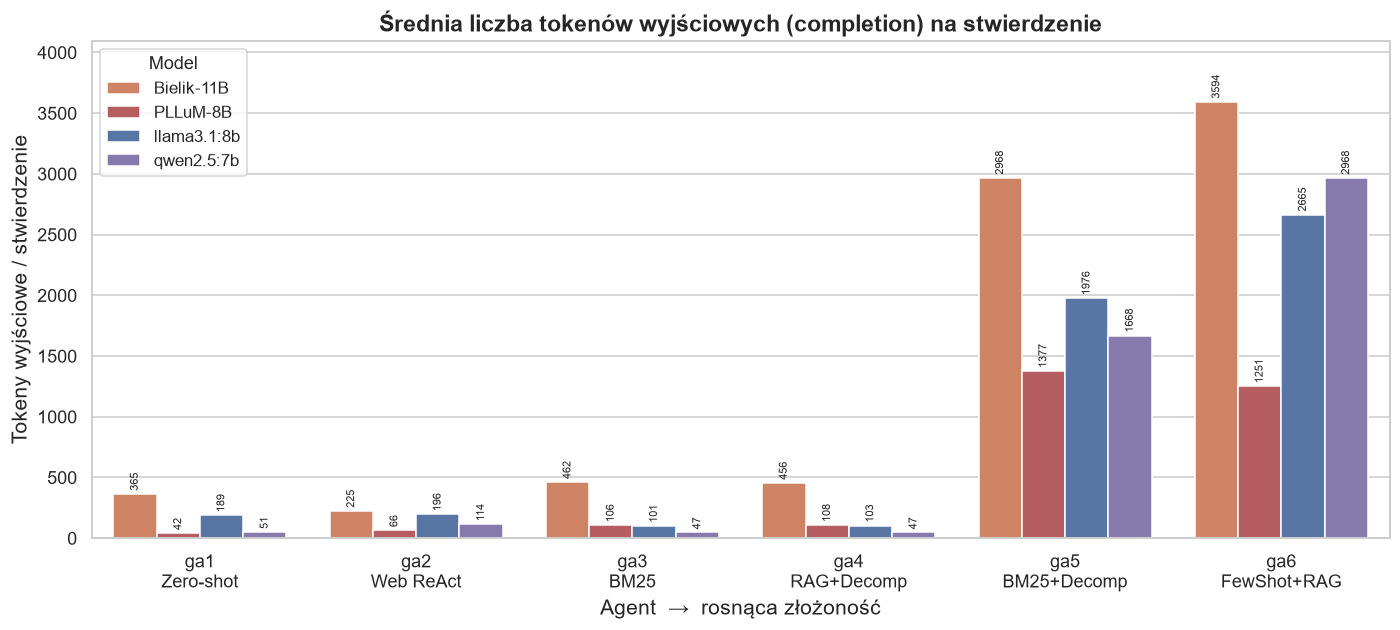

In [15]:
agent_model_bar(agent_summary, "avg_prompt",
                "Średnia liczba tokenów wejściowych (prompt) na stwierdzenie",
                "Tokeny wejściowe / stwierdzenie", fmt="%.0f", rot=90)
agent_model_bar(agent_summary, "avg_completion",
                "Średnia liczba tokenów wyjściowych (completion) na stwierdzenie",
                "Tokeny wyjściowe / stwierdzenie", fmt="%.0f", rot=90)

### Wykres 4 — Rozkłady na stwierdzenie oraz wydajność względem dokładności

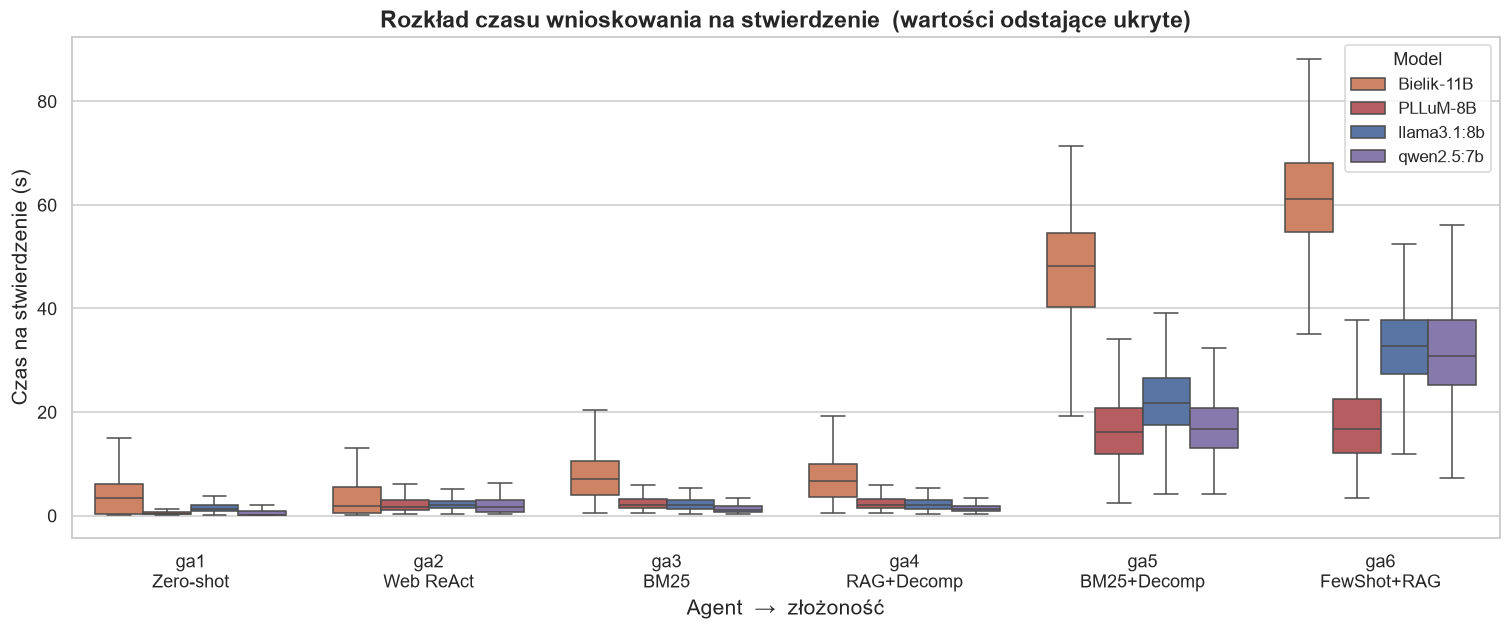

In [16]:
# 4a — czas (osobny wykres)
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df, x="label", y="time_thought", hue="model",
            order=LABEL_ORDER, hue_order=MODEL_ORDER, palette=PALETTE,
            showfliers=False, ax=ax)
ax.set_title("Rozkład czasu wnioskowania na stwierdzenie  (wartości odstające ukryte)",
             fontsize=15, fontweight="bold")
ax.set_ylabel("Czas na stwierdzenie (s)"); ax.set_xlabel("Agent  →  złożoność")
ax.tick_params(axis="x", labelsize=12); ax.legend(title="Model", fontsize=11)
plt.tight_layout(); plt.show()

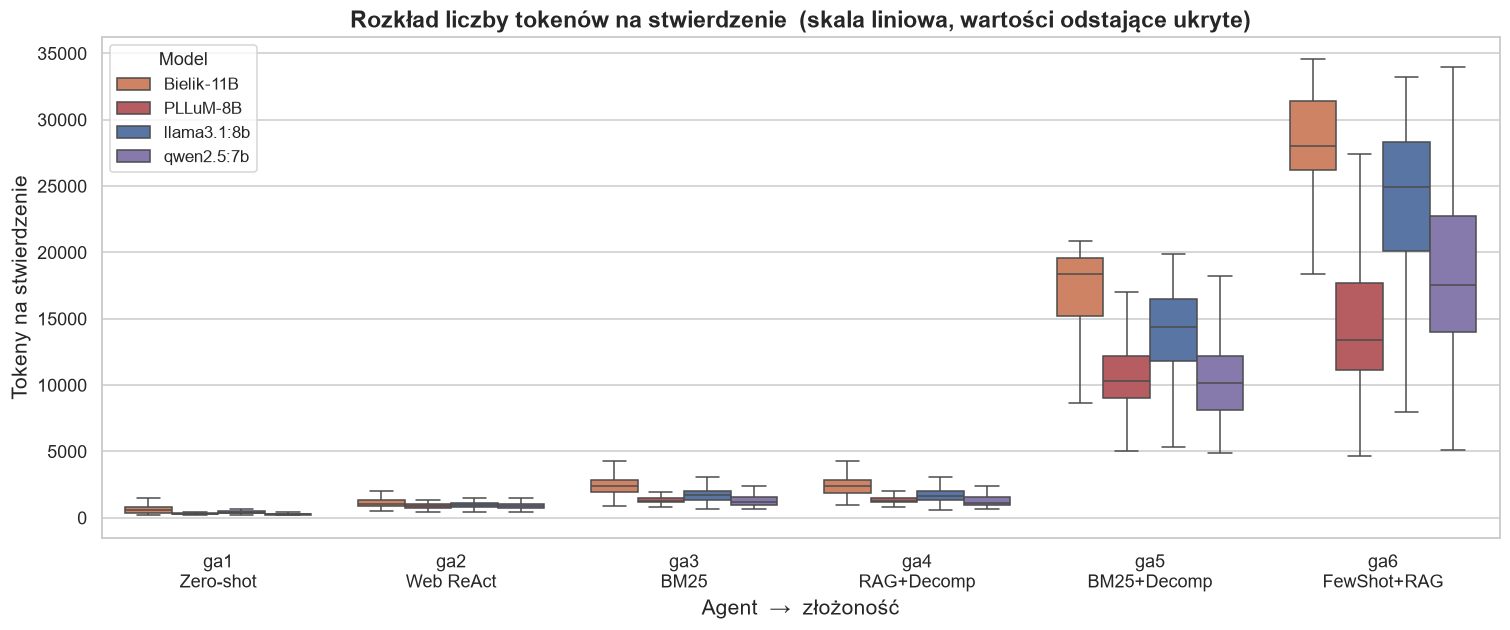

In [17]:
# 4b — tokeny (osobny wykres, skala liniowa)
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df, x="label", y="total_tokens", hue="model",
            order=LABEL_ORDER, hue_order=MODEL_ORDER, palette=PALETTE,
            showfliers=False, ax=ax)
ax.set_title("Rozkład liczby tokenów na stwierdzenie  (skala liniowa, wartości odstające ukryte)",
             fontsize=15, fontweight="bold")
ax.set_ylabel("Tokeny na stwierdzenie"); ax.set_xlabel("Agent  →  złożoność")
ax.tick_params(axis="x", labelsize=12); ax.legend(title="Model", fontsize=11)
plt.tight_layout(); plt.show()

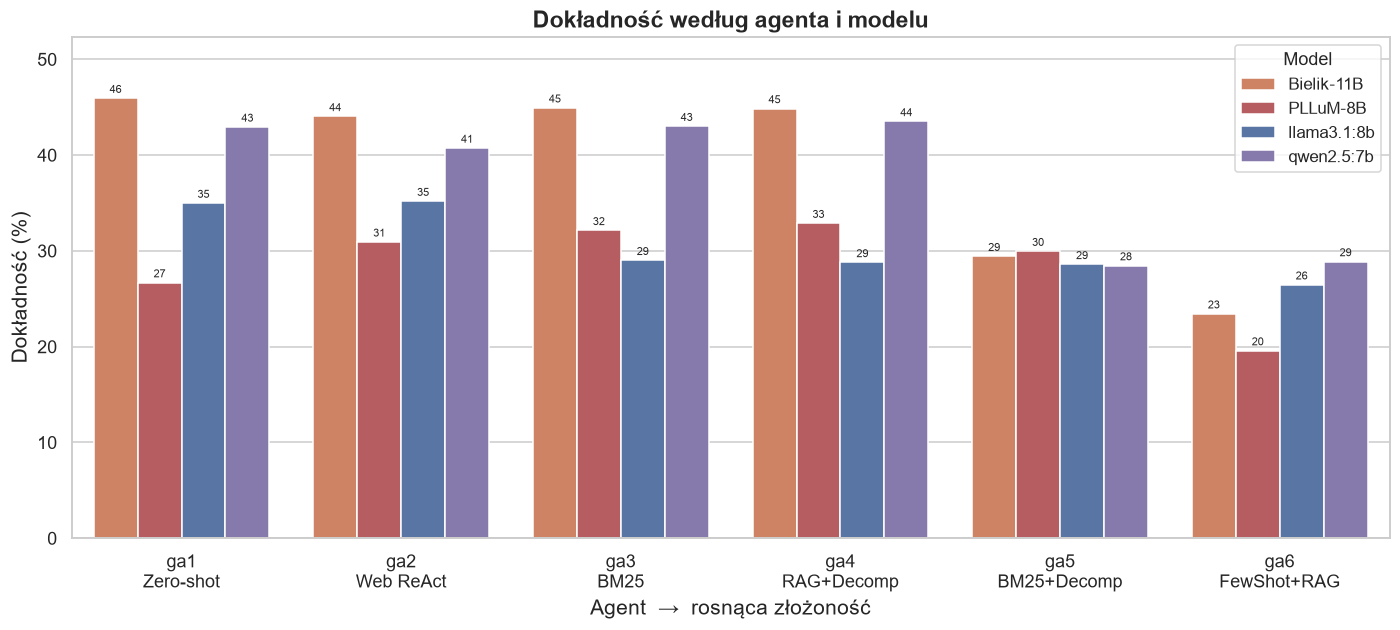

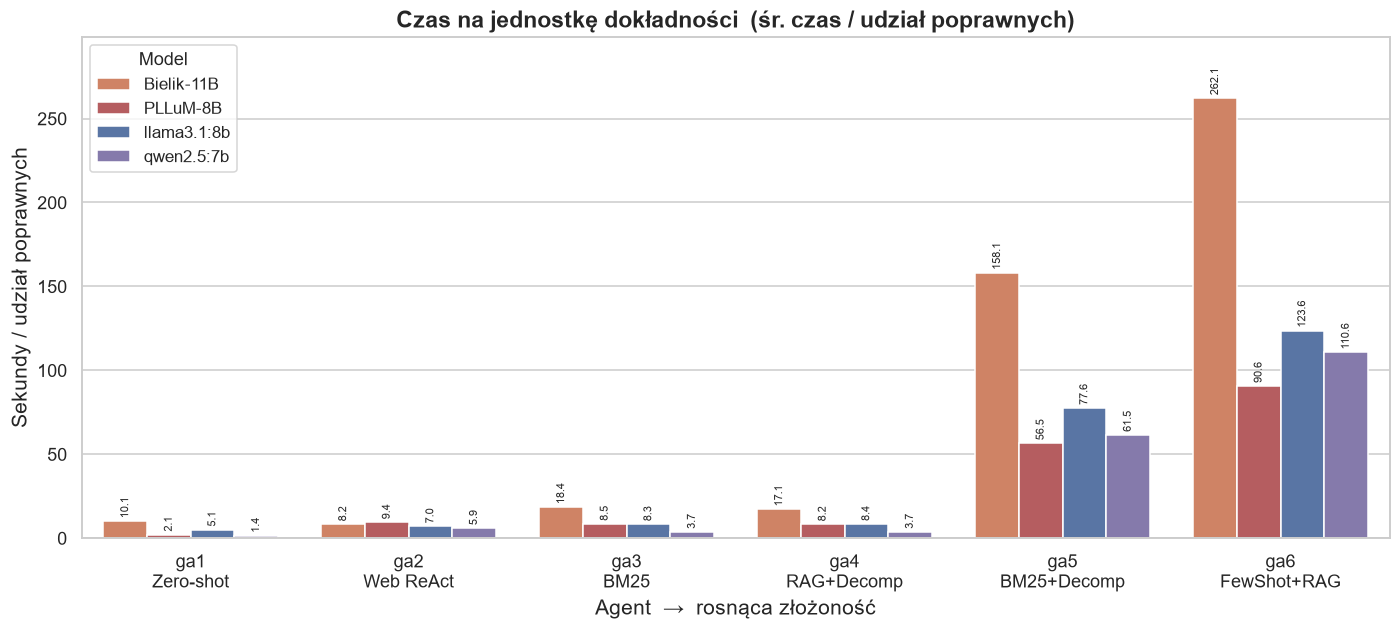

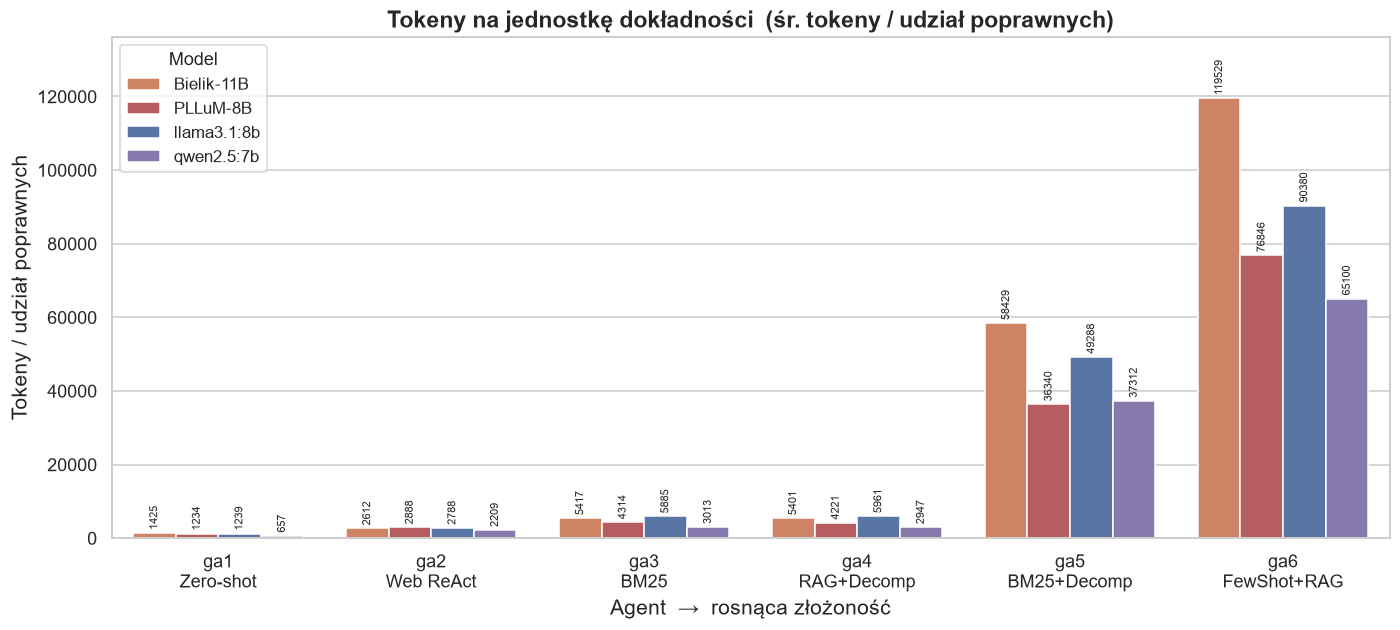

In [18]:
# 4c/4d/4e — dokladnosc oraz koszt na jednostke dokladnosci
agent_model_bar(agent_summary, "accuracy_pct",
                "Dokładność według agenta i modelu", "Dokładność (%)", fmt="%.0f")
agent_model_bar(eff, "time_per_acc",
                "Czas na jednostkę dokładności  (śr. czas / udział poprawnych)",
                "Sekundy / udział poprawnych", fmt="%.1f", rot=90)
agent_model_bar(eff, "tokens_per_acc",
                "Tokeny na jednostkę dokładności  (śr. tokeny / udział poprawnych)",
                "Tokeny / udział poprawnych", fmt="%.0f", rot=90)

### Wykres 5 — Etykiety przewidywane vs rzeczywiste i macierze pomyłek

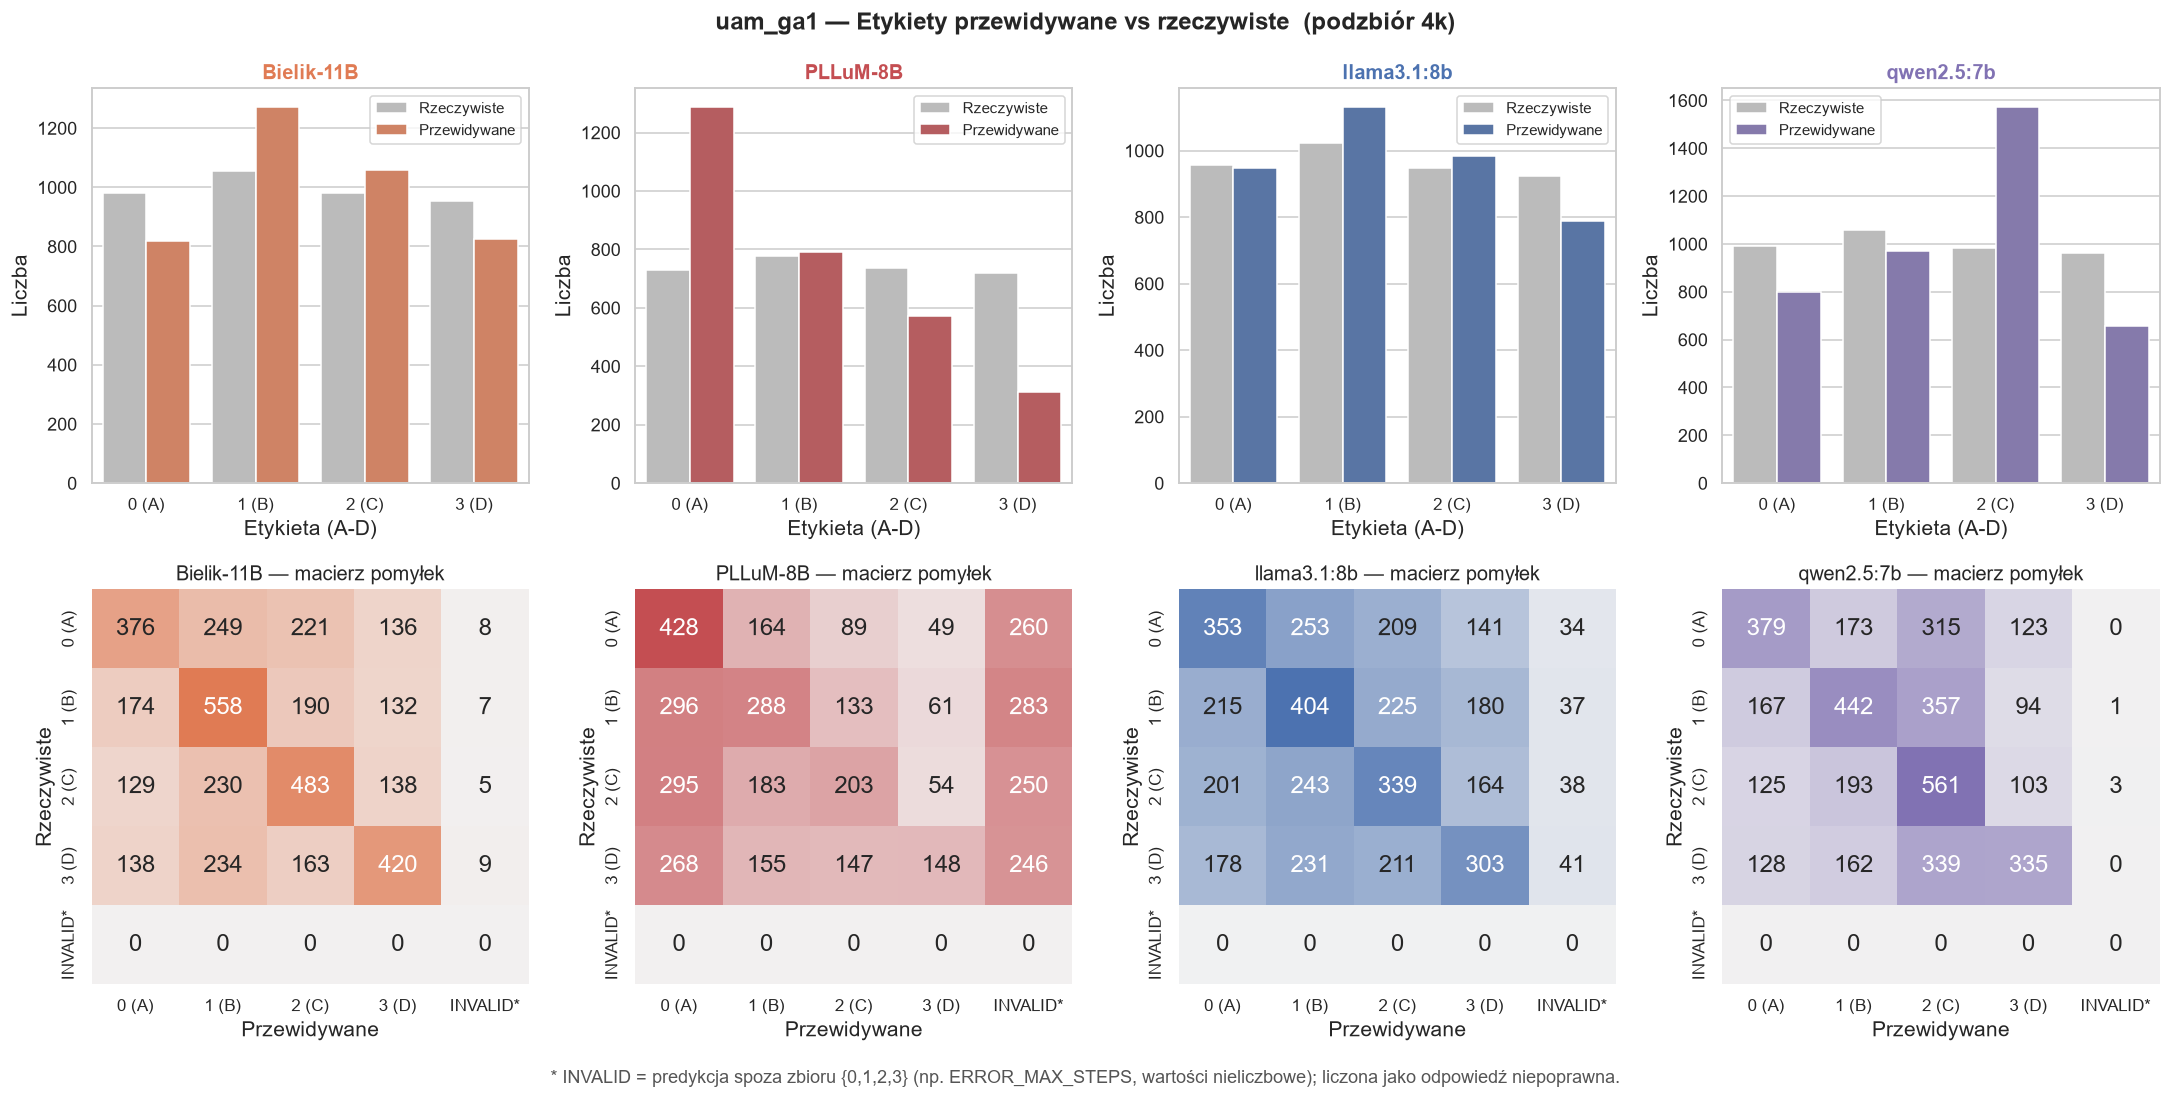

In [19]:
from sklearn.metrics import confusion_matrix

AGENT_CM = "uam_ga1"
ANS = {"0": "0 (A)", "1": "1 (B)", "2": "2 (C)", "3": "3 (D)"}
LABELS_CM = ["0", "1", "2", "3", "INVALID"]
TICKS_CM  = ["0 (A)", "1 (B)", "2 (C)", "3 (D)", "INVALID*"]
sub = df[df.base_agent == AGENT_CM]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle(f"{AGENT_CM} — Etykiety przewidywane vs rzeczywiste  (podzbiór 4k)",
             fontsize=16, fontweight="bold")
for j, m in enumerate(MODEL_ORDER):
    g = sub[sub.model == m]
    gv = g[g.model_label.isin(VALID)]
    ldf = pd.concat([
        gv["original_label"].rename("label").to_frame().assign(source="Rzeczywiste"),
        gv["model_label"].rename("label").to_frame().assign(source="Przewidywane"),
    ], ignore_index=True)
    ldf["label"] = ldf["label"].map(ANS)
    sns.countplot(data=ldf, x="label", hue="source",
                  order=[ANS[k] for k in ["0", "1", "2", "3"]],
                  palette={"Rzeczywiste": "#bbbbbb", "Przewidywane": PALETTE[m]},
                  ax=axes[0, j])
    axes[0, j].set_title(m, fontsize=13, color=PALETTE[m], fontweight="bold")
    axes[0, j].set_xlabel("Etykieta (A-D)"); axes[0, j].set_ylabel("Liczba")
    axes[0, j].legend(fontsize=10, title=""); axes[0, j].tick_params(axis="x", labelsize=11)

    cm = confusion_matrix(g["original_label"], g["pred_bucket"], labels=LABELS_CM)
    sns.heatmap(cm, annot=True, fmt="d", cmap=sns.light_palette(PALETTE[m], as_cmap=True),
                cbar=False, xticklabels=TICKS_CM, yticklabels=TICKS_CM, ax=axes[1, j])
    axes[1, j].set_title(f"{m} — macierz pomyłek", fontsize=13)
    axes[1, j].set_xlabel("Przewidywane"); axes[1, j].set_ylabel("Rzeczywiste")
    axes[1, j].tick_params(axis="both", labelsize=11)
fig.text(0.5, 0.005,
         "* INVALID = predykcja spoza zbioru {0,1,2,3} (np. ERROR_MAX_STEPS, wartości "
         "nieliczbowe); liczona jako odpowiedź niepoprawna.",
         ha="center", fontsize=12, color="#555")
plt.tight_layout(rect=[0, 0.02, 1, 1]); plt.show()

### Wykres 6 — Tokeny wejściowe vs wyjściowe (wszyscy agenci, przeskalowane + statystyki)

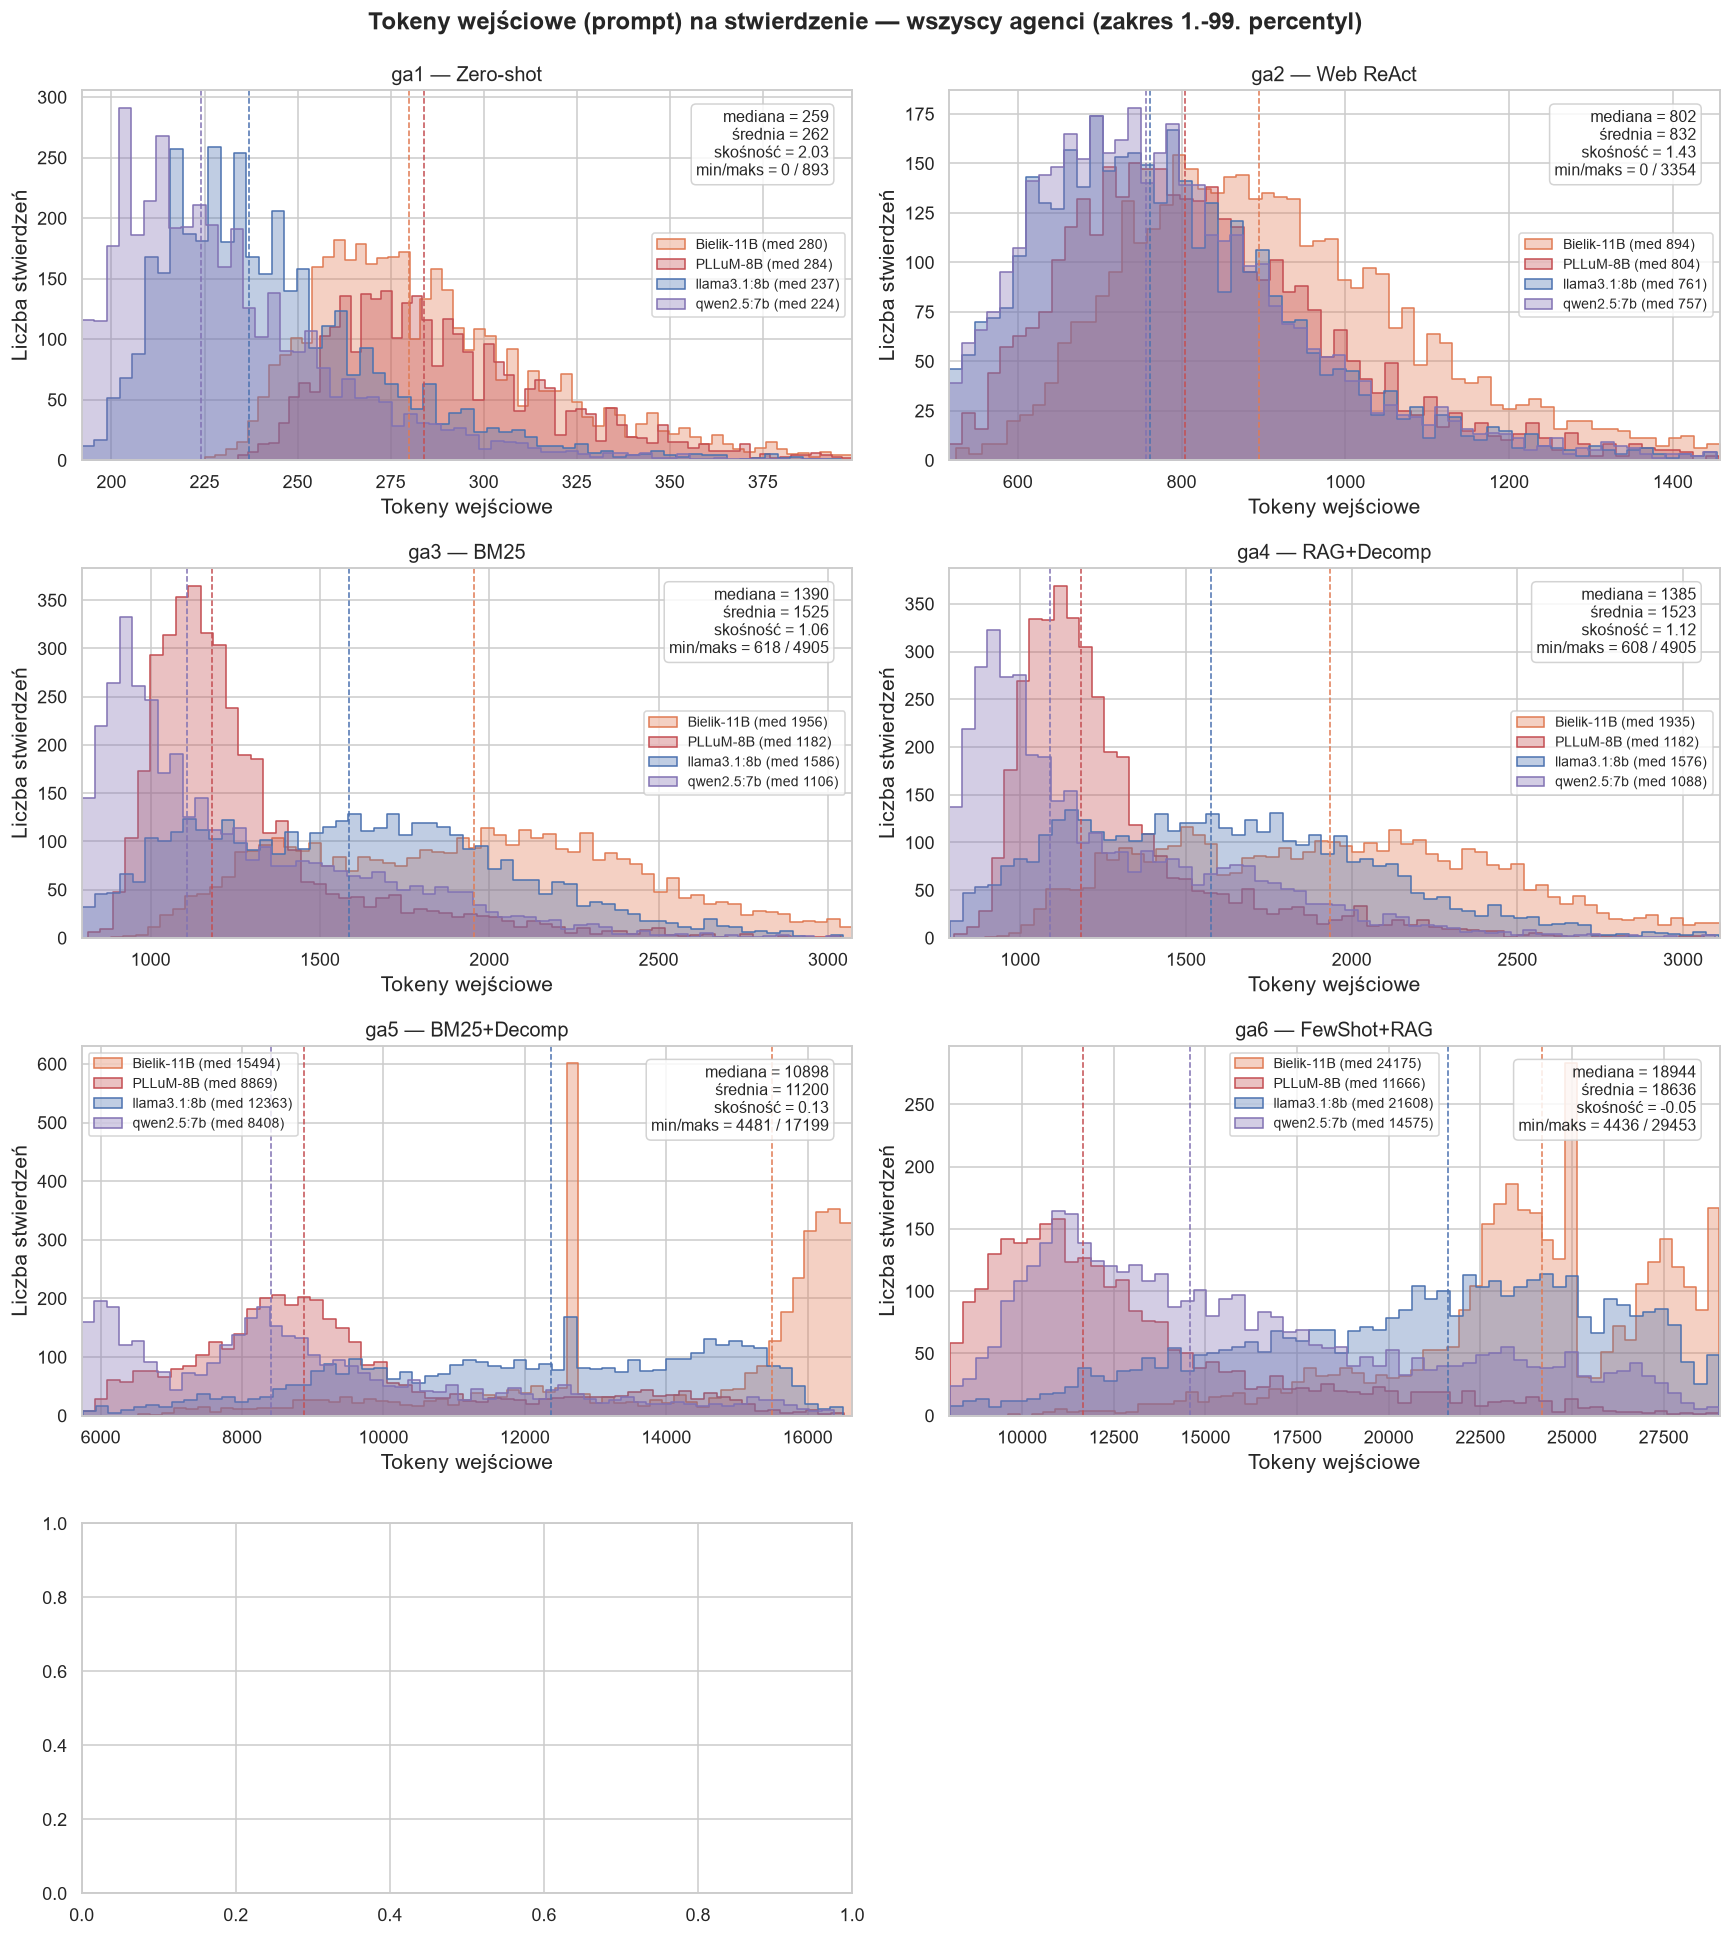

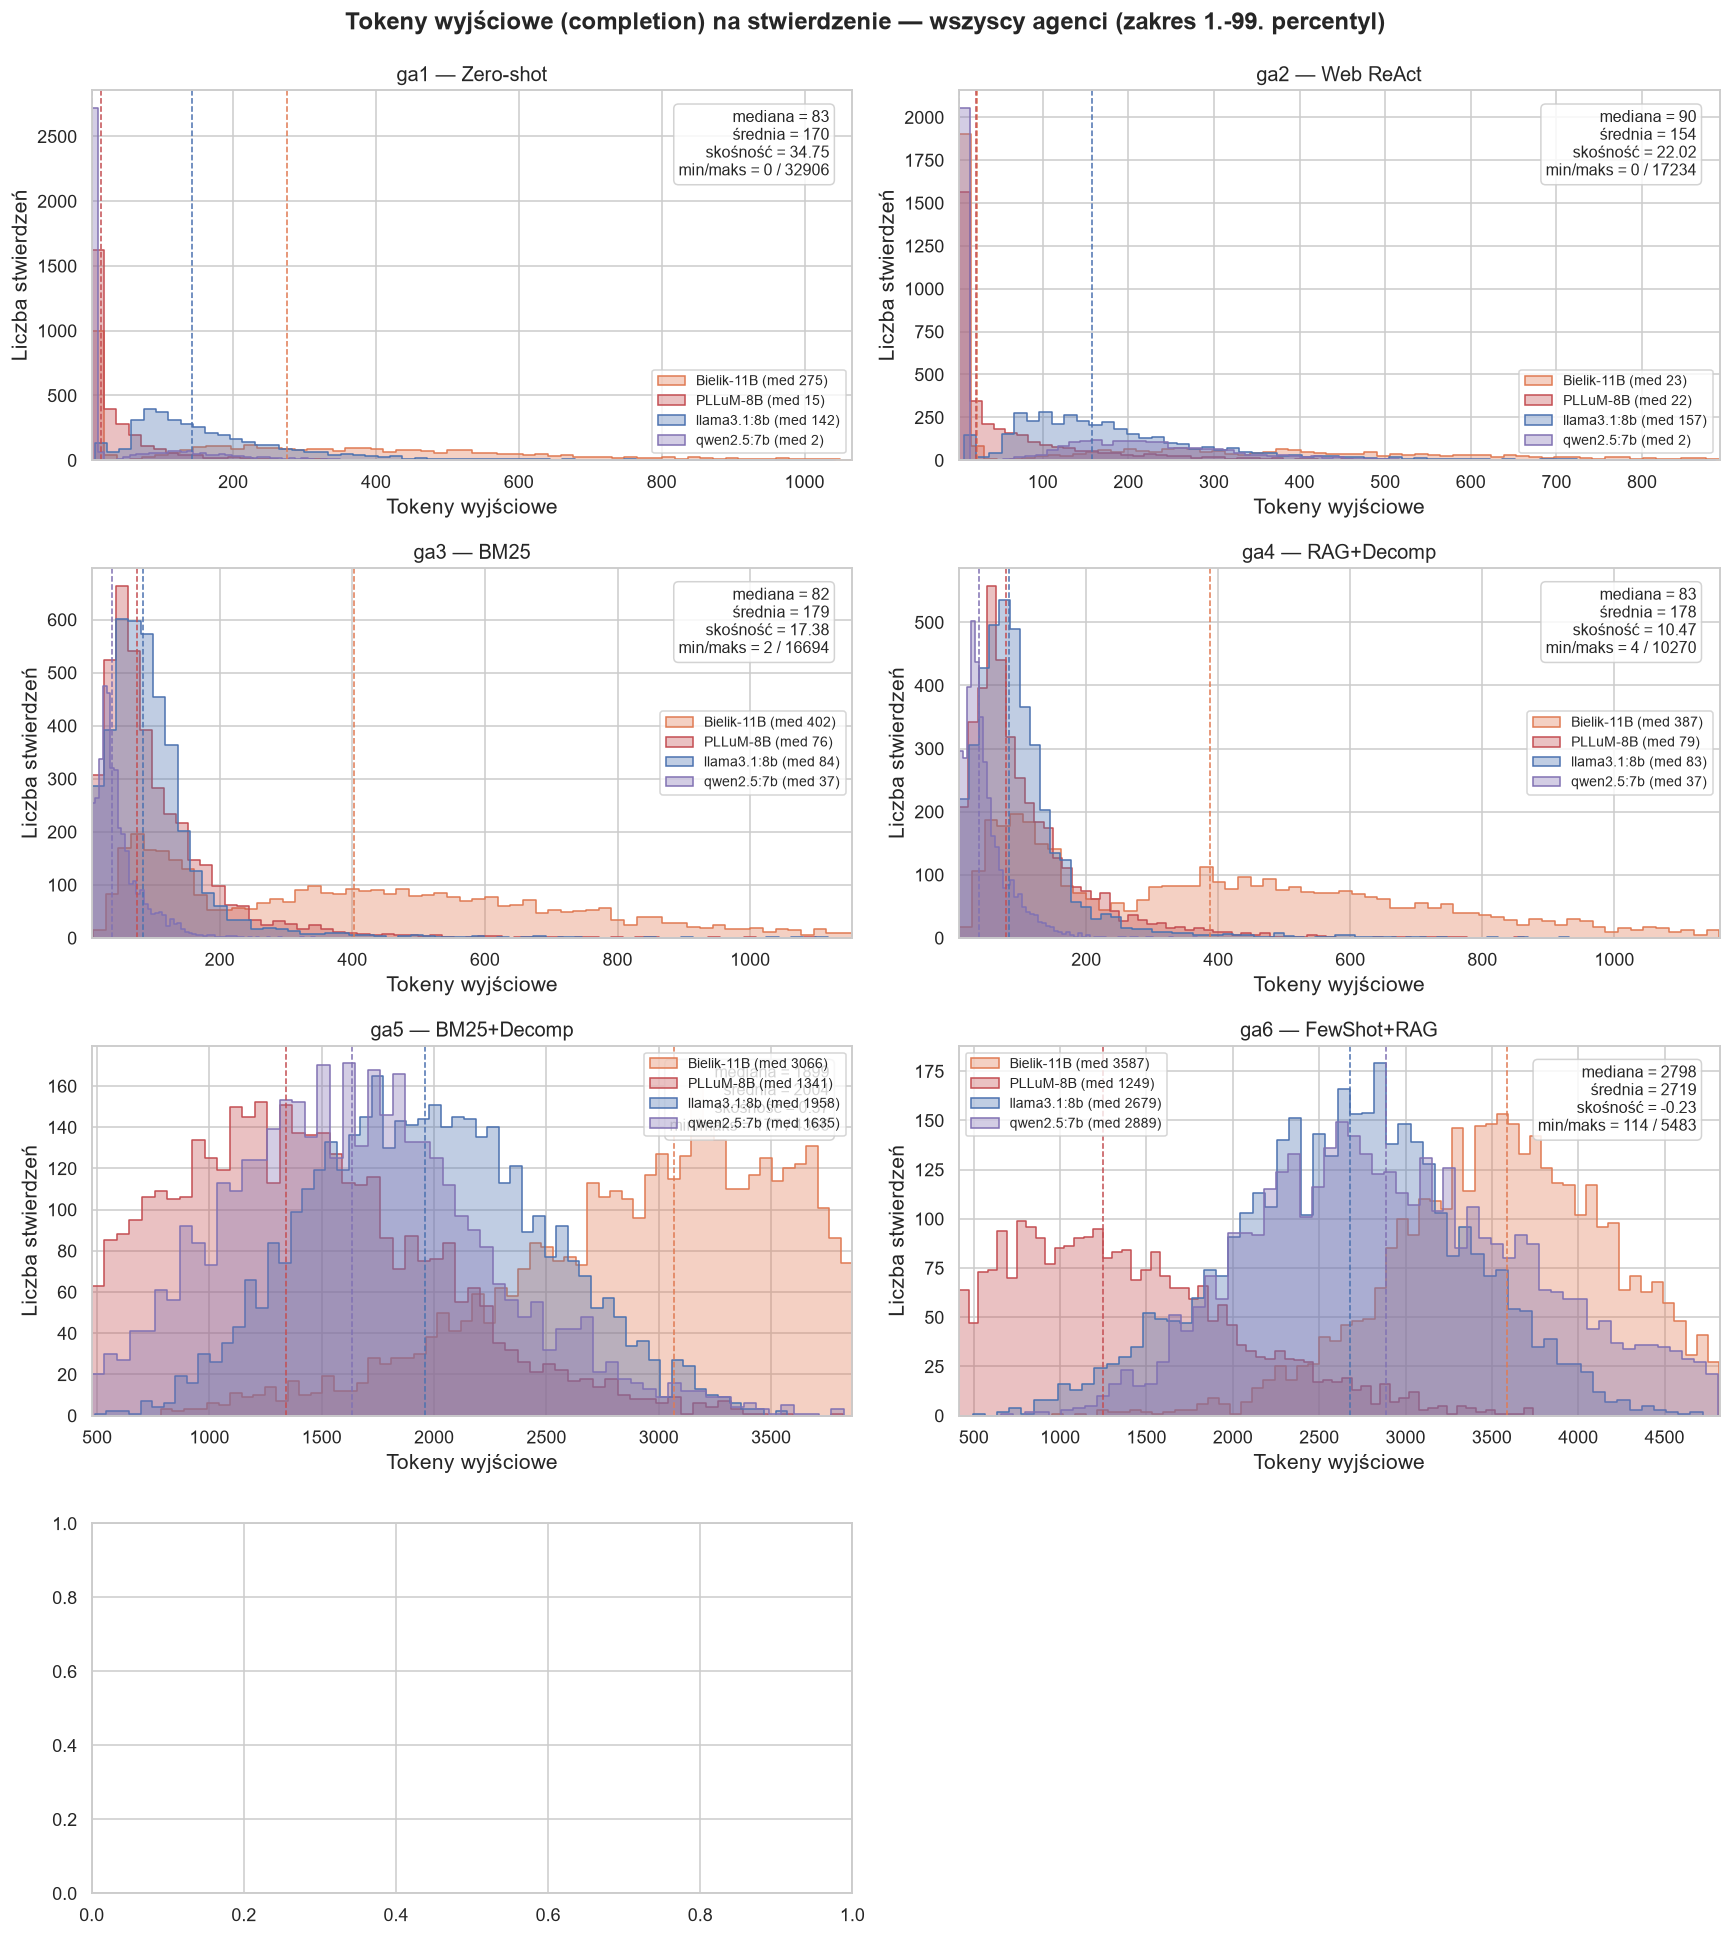

In [20]:
from scipy.stats import skew

def token_facets(col, title, xlabel):
    fig, axes = plt.subplots(4, 2, figsize=(16, 18))
    axes = axes.ravel()
    for i, ga in enumerate(AGENT_ORDER):
        ax = axes[i]
        s_all = df[(df.base_agent == ga) & (df.model_label.isin(VALID))]
        vals = s_all[col]
        lo, hi = np.percentile(vals, [1, 99])   # przeskalowanie do realnego zakresu
        for m in MODEL_ORDER:
            g = s_all[s_all.model == m]
            v = g[(g[col] >= lo) & (g[col] <= hi)][col]
            med = g[col].median()
            sns.histplot(v, bins=60, color=PALETTE[m], alpha=0.35, element="step",
                         label=f"{m} (med {med:.0f})", ax=ax)
            ax.axvline(med, color=PALETTE[m], ls="--", lw=1)
        ax.set_xlim(lo, hi)
        stats = (f"mediana = {vals.median():.0f}\nśrednia = {vals.mean():.0f}\n"
                 f"skośność = {skew(vals):.2f}\nmin/maks = {vals.min():.0f} / {vals.max():.0f}")
        ax.text(0.97, 0.95, stats, transform=ax.transAxes, ha="right", va="top",
                fontsize=10.5, bbox=dict(boxstyle="round", fc="white", ec="#cccccc", alpha=0.85))
        ax.set_title(AGENT_META[ga][0].replace("\n", " — "), fontsize=13)
        ax.set_xlabel(xlabel); ax.set_ylabel("Liczba stwierdzeń"); ax.legend(fontsize=9)
    axes[-1].axis("off")
    fig.suptitle(title, fontsize=16, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.99]); plt.show()

token_facets("prompt_tokens",
             "Tokeny wejściowe (prompt) na stwierdzenie — wszyscy agenci (zakres 1.-99. percentyl)",
             "Tokeny wejściowe")
token_facets("completion_tokens",
             "Tokeny wyjściowe (completion) na stwierdzenie — wszyscy agenci (zakres 1.-99. percentyl)",
             "Tokeny wyjściowe")

## Wymiary benchmarku — kategorie tematów i rok egzaminu
154 surowe tematy pogrupowane w rodziny: prefiksy kodów egzaminów (R., M., …)
vs nazwane przedmioty. Dokładność łączona po agentach, o ile nie zaznaczono inaczej.

In [21]:
def topic_family(t):
    t = str(t)
    m = re.match(r"^([A-Za-z]+)\.\d", t)   # exam codes like R.13, M.39
    return (m.group(1).upper() + " (exam code)") if m else t

df["topic_family"] = df["topic"].apply(topic_family)

fam_acc = (df.pivot_table("is_correct", "topic_family", "model", "mean") * 100)
fam_acc = fam_acc.reindex(columns=MODEL_ORDER).round(1)
fam_n = df[df.model == MODEL_ORDER[0]].groupby("topic_family")["claim_id"].nunique()
fam_acc = fam_acc.assign(n_claims=fam_n).sort_values("n_claims", ascending=False)
fam_acc

model,Bielik-11B,PLLuM-8B,llama3.1:8b,qwen2.5:7b,n_claims
topic_family,,,,,
M (exam code),36.4,27.1,29.1,35.8,1393
R (exam code),40.5,29.0,31.7,38.5,1176
MG (exam code),37.7,26.8,28.8,36.1,508
RL (exam code),38.1,29.2,28.1,35.3,399
S (exam code),40.4,34.2,32.1,44.6,202
ST (exam code),52.2,36.2,42.3,55.0,143
Matematyka,30.3,22.8,28.3,32.9,82
Fizyka,39.6,41.2,29.6,45.0,40
M.YY,38.9,28.6,41.3,38.1,21


### Dokładność według rodziny tematów — kolor modelu, intensywność proporcjonalna do dokładności

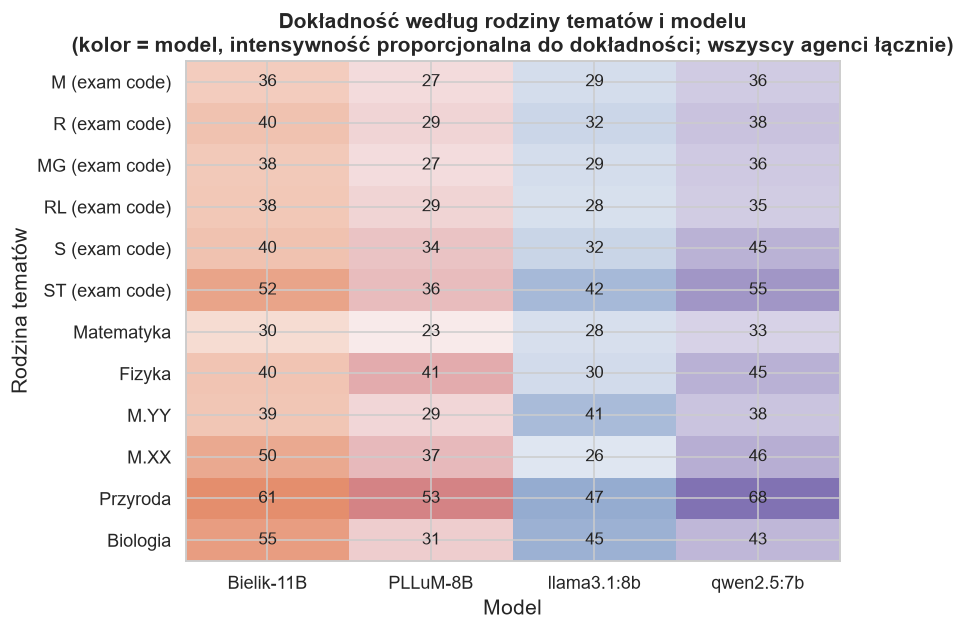

In [22]:
top_fams = fam_acc.head(12).index
data = fam_acc.loc[top_fams, MODEL_ORDER]
vmin, vmax = float(np.nanmin(data.values)), float(np.nanmax(data.values))

rgba = np.ones((len(top_fams), len(MODEL_ORDER), 4))
for j, m in enumerate(MODEL_ORDER):
    base = to_rgb(PALETTE[m])
    for i in range(len(top_fams)):
        acc = data.iloc[i, j]
        a = 0.12 + 0.88 * (acc - vmin) / (vmax - vmin) if vmax > vmin else 0.5
        rgba[i, j] = (*base, a)

fig, ax = plt.subplots(figsize=(8, max(4, len(top_fams) * 0.5)))
ax.imshow(rgba, aspect="auto")
ax.set_xticks(range(len(MODEL_ORDER))); ax.set_xticklabels(MODEL_ORDER, fontsize=12)
ax.set_yticks(range(len(top_fams))); ax.set_yticklabels(top_fams, fontsize=12)
for i in range(len(top_fams)):
    for j in range(len(MODEL_ORDER)):
        ax.text(j, i, f"{data.iloc[i, j]:.0f}", ha="center", va="center",
                fontsize=11, color="#222222")
ax.set_title("Dokładność według rodziny tematów i modelu\n"
             "(kolor = model, intensywność proporcjonalna do dokładności; wszyscy agenci łącznie)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Model"); ax.set_ylabel("Rodzina tematów")
plt.tight_layout(); plt.show()

In [23]:
# Top-N hardest / easiest individual topics (min claim count to avoid noise)
MIN_CLAIMS = 15
by_topic = (df.groupby("topic")
              .agg(n_claims=("claim_id", "nunique"),
                   accuracy=("is_correct", lambda s: s.mean() * 100))
              .query("n_claims >= @MIN_CLAIMS")
              .sort_values("accuracy"))
print(f"Topics with >= {MIN_CLAIMS} claims: {len(by_topic)}")
print("\nHardest 10 topics (pooled over models & agents):")
display(by_topic.head(10).round(1))
print("Easiest 10 topics:")
display(by_topic.tail(10).round(1))

Topics with >= 15 claims: 90

Hardest 10 topics (pooled over models & agents):


,n_claims,accuracy
topic,,
MG.03,22,22.2
MG.42,18,22.9
S.01,25,23.2
MG.14,33,25.4
RL.14,38,26.0
RL.24,21,26.2
M.02,39,26.6
M.08,44,27.0
RL.04,48,27.4


Easiest 10 topics:


,n_claims,accuracy
topic,,
R.07,56,41.1
S.03,38,41.7
S.04,20,42.9
S.02,27,44.8
R.06,82,45.3
ST.05,37,45.9
R.10,50,47.2
ST.04,54,47.3
ST.02,37,47.7


### Dokładność według roku egzaminu — łącznie oraz z podziałem na agentów

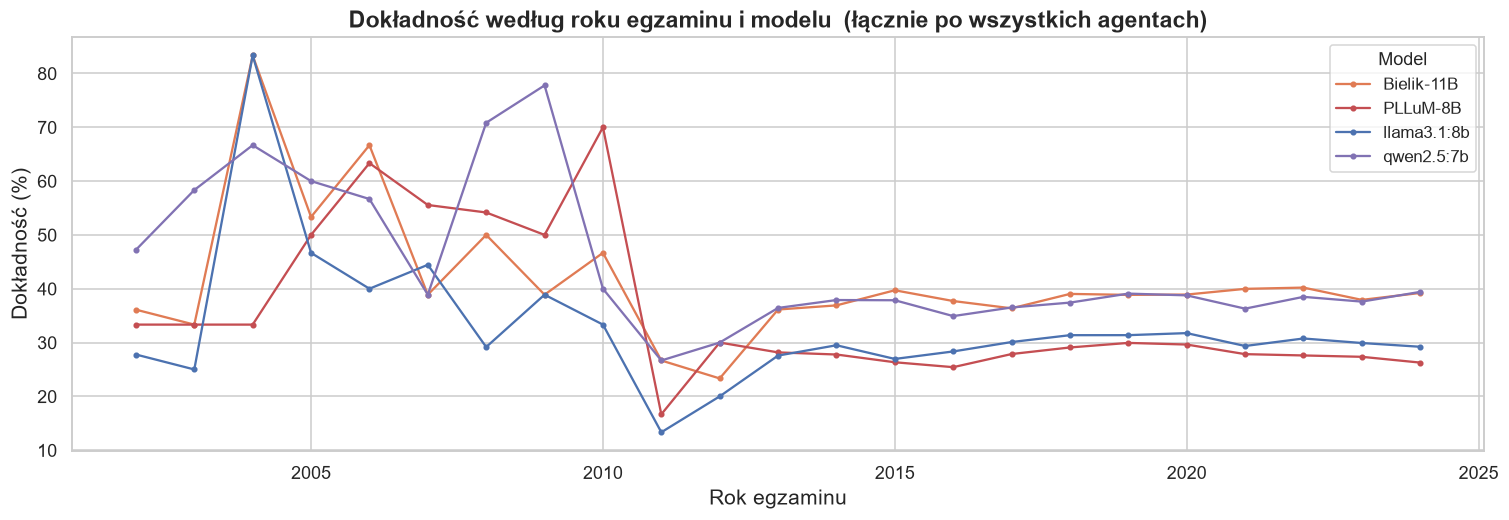

In [24]:
# Lacznie po wszystkich agentach (wersja zbiorcza)
yr = (df.dropna(subset=["year"]).pivot_table("is_correct", "year", "model", "mean") * 100)
yr = yr.reindex(columns=MODEL_ORDER)
fig, ax = plt.subplots(figsize=(14, 5))
for m in MODEL_ORDER:
    ax.plot(yr.index, yr[m], marker="o", ms=3, color=PALETTE[m], label=m)
ax.set_title("Dokładność według roku egzaminu i modelu  (łącznie po wszystkich agentach)",
             fontsize=15, fontweight="bold")
ax.set_xlabel("Rok egzaminu"); ax.set_ylabel("Dokładność (%)")
ax.legend(title="Model", fontsize=11)
plt.tight_layout(); plt.show()

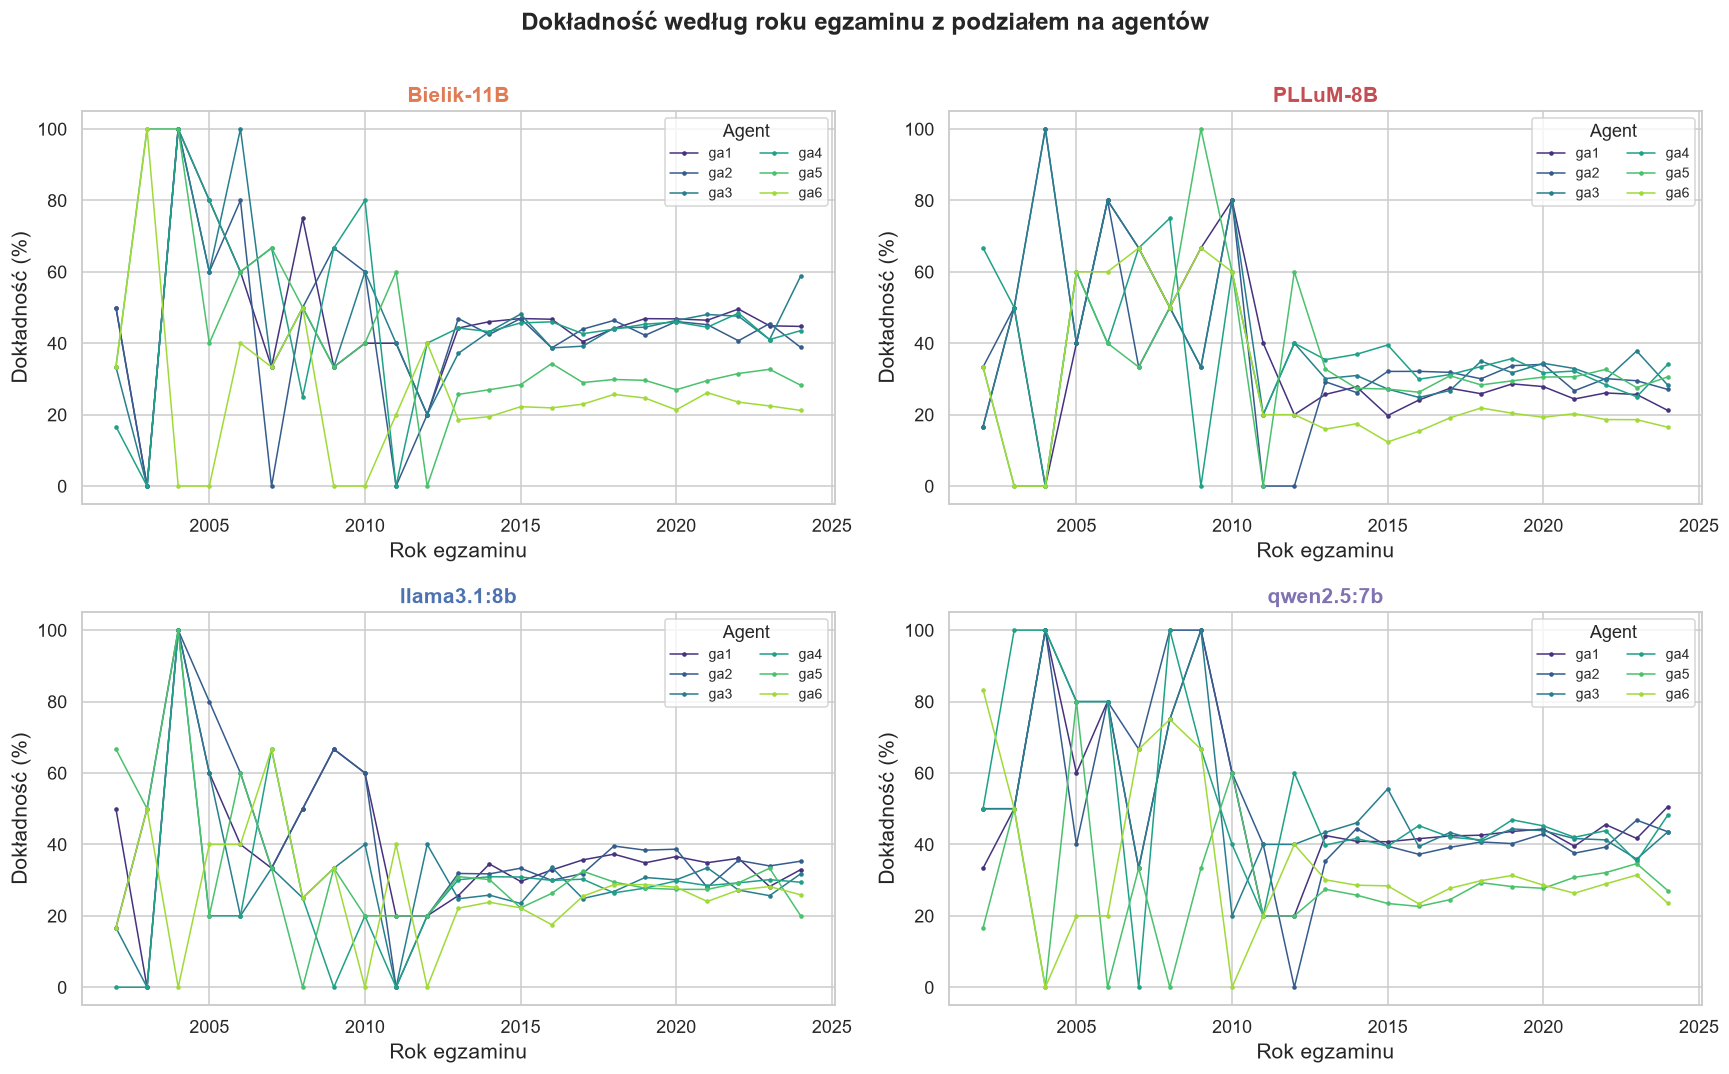

In [25]:
# Podzial na agentow: panel per model, linia per agent
dy = df.dropna(subset=["year"])
agent_colors = sns.color_palette("viridis", len(AGENT_ORDER))
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Dokładność według roku egzaminu z podziałem na agentów",
             fontsize=16, fontweight="bold")
for ax, m in zip(axes.ravel(), MODEL_ORDER):
    piv = (dy[dy.model == m].pivot_table("is_correct", "year", "base_agent", "mean") * 100)
    piv = piv.reindex(columns=AGENT_ORDER)
    for k, ga in enumerate(AGENT_ORDER):
        if ga in piv:
            ax.plot(piv.index, piv[ga], marker="o", ms=2, lw=1,
                    color=agent_colors[k], label=AGENT_META[ga][0].split("\n")[0])
    ax.set_title(m, fontsize=14, color=PALETTE[m], fontweight="bold")
    ax.set_xlabel("Rok egzaminu"); ax.set_ylabel("Dokładność (%)")
    ax.legend(fontsize=9, ncol=2, title="Agent")
plt.tight_layout(rect=[0, 0, 1, 0.98]); plt.show()